In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive

MyDrive


In [3]:
!ls /content/drive/MyDrive/PII

genuine.zip


In [165]:
import shutil
import os

SRC_ZIP = "/content/drive/MyDrive/PII/genuine.zip"
DST_ZIP = "/content/genuine.zip"

print("Copiando ZIP a disco local...")
shutil.copy2(SRC_ZIP, DST_ZIP)
print("ZIP copiado a /content/")


Copiando ZIP a disco local...
ZIP copiado a /content/


In [17]:
import zipfile

with zipfile.ZipFile("/content/genuine.zip", "r") as z:
    for name in z.namelist()[:30]:
        print(name)

genuine/
genuine/chanel/
genuine/chanel/bag---2.55/
genuine/chanel/bag---2.55/1/
genuine/chanel/bag---2.55/1/1.jpg
genuine/chanel/bag---2.55/1/10.jpg
genuine/chanel/bag---2.55/1/2.jpg
genuine/chanel/bag---2.55/1/3.jpg
genuine/chanel/bag---2.55/1/4.jpg
genuine/chanel/bag---2.55/1/5.jpg
genuine/chanel/bag---2.55/1/6.jpg
genuine/chanel/bag---2.55/1/7.jpg
genuine/chanel/bag---2.55/1/8.jpg
genuine/chanel/bag---2.55/1/9.jpg
genuine/chanel/bag---2.55/10/
genuine/chanel/bag---2.55/10/1.jpg
genuine/chanel/bag---2.55/10/10.jpg
genuine/chanel/bag---2.55/10/11.jpg
genuine/chanel/bag---2.55/10/12.jpg
genuine/chanel/bag---2.55/10/2.jpg
genuine/chanel/bag---2.55/10/3.jpg
genuine/chanel/bag---2.55/10/4.jpg
genuine/chanel/bag---2.55/10/5.jpg
genuine/chanel/bag---2.55/10/6.jpg
genuine/chanel/bag---2.55/10/7.jpg
genuine/chanel/bag---2.55/10/8.jpg
genuine/chanel/bag---2.55/10/9.jpg
genuine/chanel/bag---2.55/100/
genuine/chanel/bag---2.55/100/1.jpg
genuine/chanel/bag---2.55/100/10.jpg


In [166]:
import zipfile

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Descomprimiendo ZIP en /content/data...")
with zipfile.ZipFile(DST_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset descomprimido en /content/data")

Descomprimiendo ZIP en /content/data...
Dataset descomprimido en /content/data


In [19]:
!ls /content/data/genuine/chanel

bag---2.55  bag---boy  bag---gabrielle	bag---timeless


# SPLIT 70 / 15 / 15

In [32]:
import os
import random
import shutil
from math import floor

GENUINE_DIR = "/content/data/genuine/chanel"
SPLIT_DIR = "/content/data/split"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

random.seed(42)

# Limpiar split previo
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
os.makedirs(SPLIT_DIR, exist_ok=True)

for model in sorted(os.listdir(GENUINE_DIR)):
    model_path = os.path.join(GENUINE_DIR, model)
    if not os.path.isdir(model_path):
        continue

    bag_ids = [
        d for d in os.listdir(model_path)
        if os.path.isdir(os.path.join(model_path, d))
    ]

    random.shuffle(bag_ids)

    n_total = len(bag_ids)
    n_train = floor(n_total * TRAIN_RATIO)
    n_val = floor(n_total * VAL_RATIO)

    train_ids = bag_ids[:n_train]
    val_ids = bag_ids[n_train:n_train + n_val]
    test_ids = bag_ids[n_train + n_val:]

    print(
        f"{model}: total={n_total} | "
        f"train={len(train_ids)} | "
        f"val={len(val_ids)} | "
        f"test={len(test_ids)}"
    )

    for split_name, ids in {
        "train": train_ids,
        "val": val_ids,
        "test": test_ids
    }.items():
        for bag_id in ids:
            src = os.path.join(model_path, bag_id)
            dst = os.path.join(SPLIT_DIR, split_name, model, bag_id)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copytree(src, dst)


bag---2.55: total=357 | train=249 | val=53 | test=55
bag---boy: total=299 | train=209 | val=44 | test=46
bag---gabrielle: total=242 | train=169 | val=36 | test=37
bag---timeless: total=340 | train=237 | val=51 | test=52


# Verificación train / val / test

In [33]:
for split in ["train", "val", "test"]:
    print(f"\nSplit: {split}")
    for model in os.listdir(os.path.join("/content/data/split", split)):
        n = len(os.listdir(os.path.join("/content/data/split", split, model)))
        print(f"  {model}: {n} carteras")


Split: train
  bag---timeless: 237 carteras
  bag---2.55: 249 carteras
  bag---gabrielle: 169 carteras
  bag---boy: 209 carteras

Split: val
  bag---timeless: 51 carteras
  bag---2.55: 53 carteras
  bag---gabrielle: 36 carteras
  bag---boy: 44 carteras

Split: test
  bag---timeless: 52 carteras
  bag---2.55: 55 carteras
  bag---gabrielle: 37 carteras
  bag---boy: 46 carteras


# Verificación  train / val / test

In [34]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

# Transforms

Train (CON data augmentation)

In [58]:
from torchvision import transforms

IMG_SIZE = 224

train_transform = transforms.Compose([
    # PIL transforms
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.75, 1.0)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.15
    ),
    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3)],
        p=0.3
    ),

    # PIL → Tensor
    transforms.ToTensor(),

    # Tensor transforms
    transforms.RandomErasing(
        p=0.15,
        scale=(0.02, 0.06)
    ),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


Validation / Test (SIN augmentation)

In [59]:
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset personalizado

In [60]:
import os
from PIL import Image
from torch.utils.data import Dataset

class HandbagDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        root_dir:
          /content/data/split/train
          /content/data/split/val
          /content/data/split/test
        """
        self.samples = []
        self.transform = transform

        image_exts = (".jpg", ".jpeg", ".png", ".webp")

        for model in sorted(os.listdir(root_dir)):
            model_path = os.path.join(root_dir, model)
            if not os.path.isdir(model_path):
                continue

            for bag_id in os.listdir(model_path):
                bag_path = os.path.join(model_path, bag_id)
                if not os.path.isdir(bag_path):
                    continue

                for img_name in os.listdir(bag_path):
                    if img_name.lower().endswith(image_exts):
                        self.samples.append(
                            os.path.join(bag_path, img_name)
                        )

        print(f" {len(self.samples)} imágenes encontradas en {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path = self.samples[idx]

        img = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            img = self.transform(img)

        return img



In [62]:
img1 = train_dataset[0]
img2 = train_dataset[0]

print(torch.allclose(img1, img2))


True


Verificación

In [167]:
train_dataset = HandbagDataset(
    root_dir="/content/data/split/train",
    transform=train_transform
)

print("Total imágenes train:", len(train_dataset))


📦 7408 imágenes encontradas en /content/data/split/train
Total imágenes train: 7408


# Crear DataLoaders

In [65]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32          # recomendado para EfficientNet
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_dataset = HandbagDataset(
    root_dir="/content/data/split/val",
    transform=eval_transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_dataset = HandbagDataset(
    root_dir="/content/data/split/test",
    transform=eval_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)



📦 1638 imágenes encontradas en /content/data/split/val
📦 1551 imágenes encontradas en /content/data/split/test


# Verificación

In [66]:
batch = next(iter(train_loader))
print("Batch type:", type(batch))
print("Batch shape:", batch.shape)
print("Batch dtype:", batch.dtype)



Batch type: <class 'torch.Tensor'>
Batch shape: torch.Size([32, 3, 224, 224])
Batch dtype: torch.float32


# MODELO

In [67]:
import torch
import torch.nn as nn
from torchvision import models

In [68]:
class EfficientNetEmbedding(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()

        # Backbone preentrenado
        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        # Dimensión de salida del backbone
        in_features = self.backbone.classifier[1].in_features

        # Quitamos el clasificador original
        self.backbone.classifier = nn.Identity()

        # Proyección a embedding
        self.embedding = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

    def forward(self, x):
        features = self.backbone(x)
        emb = self.embedding(features)
        return emb


# Crear el modelo

In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EfficientNetEmbedding(embedding_dim=256).to(device)
model


EfficientNetEmbedding(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
           

# FUNCIÓN PARA CALCULAR EL CENTRO

In [70]:
@torch.no_grad()
def compute_center(model, dataloader, device):
    model.eval()
    embeddings = []

    for batch in dataloader:
        batch = batch.to(device)
        emb = model(batch)
        embeddings.append(emb.cpu())  # ← liberar GPU

    embeddings = torch.cat(embeddings, dim=0)
    center = embeddings.mean(dim=0).to(device)

    return center



# CALCULAR EL CENTRO USANDO TRAIN

In [71]:
import torch
import shutil
import os

# RUTAS
CENTER_LOCAL = "/content/oneclass_center.pt"
CENTER_DRIVE = "/content/drive/MyDrive/PII/oneclass_center.pt"

# Guardar en Colab
torch.save(center, CENTER_LOCAL)
print("Centro guardado en Colab:", CENTER_LOCAL)

# Copiar a Drive
os.makedirs(os.path.dirname(CENTER_DRIVE), exist_ok=True)
shutil.copy2(CENTER_LOCAL, CENTER_DRIVE)

print("Centro guardado en Drive:", CENTER_DRIVE)


Centro guardado en Colab: /content/oneclass_center.pt
Centro guardado en Drive: /content/drive/MyDrive/PII/oneclass_center.pt


DEFINIR LA LOSS ONE-CLASS (Deep SVDD)

In [72]:
class OneClassLoss(torch.nn.Module):
    def __init__(self, center):
        super().__init__()
        self.register_buffer("center", center)

    def forward(self, embeddings):
        distances = torch.sum((embeddings - self.center) ** 2, dim=1)
        return distances.mean()


In [73]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-6
)


In [74]:
model.train()

# recomendación aplicada: mover la loss al device
loss_fn = OneClassLoss(center).to(device)

batch = next(iter(train_loader)).to(device)
emb = model(batch)
loss = loss_fn(emb)

print("Loss inicial:", loss.item())

Loss inicial: 276.8799133300781


In [ ]:
# LOOP DE ENTRENAMIENTO

In [76]:
EPOCHS = 10
LOG_INTERVAL = 1

In [77]:
from tqdm import tqdm

# mover la loss al device
loss_fn = OneClassLoss(center).to(device)

history = {
    "train_loss": [],
    "val_loss": []
}

for epoch in range(1, EPOCHS + 1):

    # TRAIN
    model.train()
    train_losses = []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        batch = batch.to(device)

        optimizer.zero_grad()
        embeddings = model(batch)
        loss = loss_fn(embeddings)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    train_loss = sum(train_losses) / len(train_losses)
    history["train_loss"].append(train_loss)

    # VAL
    model.eval()
    val_losses = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            embeddings = model(batch)
            loss = loss_fn(embeddings)
            val_losses.append(loss.item())

    val_loss = sum(val_losses) / len(val_losses)
    history["val_loss"].append(val_loss)

    if epoch % LOG_INTERVAL == 0:
        print(
            f"Epoch {epoch}: "
            f"Train Loss = {train_loss:.6f} | "
            f"Val Loss = {val_loss:.6f}"
        )



Epoch 1/10 [Train]: 100%|██████████| 232/232 [01:22<00:00,  2.80it/s]


Epoch 1: Train Loss = 103.010644 | Val Loss = 240.324559


Epoch 2/10 [Train]: 100%|██████████| 232/232 [01:21<00:00,  2.86it/s]


Epoch 2: Train Loss = 17.971865 | Val Loss = 85.488534


Epoch 3/10 [Train]: 100%|██████████| 232/232 [01:22<00:00,  2.83it/s]


...

Epoch 8: Train Loss = 7.782543 | Val Loss = 143.832333


Epoch 9/10 [Train]: 100%|██████████| 232/232 [01:21<00:00,  2.83it/s]


Epoch 9: Train Loss = 6.761659 | Val Loss = 151.844103


Epoch 10/10 [Train]: 100%|██████████| 232/232 [01:23<00:00,  2.77it/s]


Epoch 10: Train Loss = 5.849321 | Val Loss = 168.158151


In [168]:
import os
import shutil
import torch

# guardar en Colab
MODEL_LOCAL = "/content/handbag_oneclass_efficientnet.h5"
torch.save(model.state_dict(), MODEL_LOCAL)
print(f" Modelo guardado en Colab: {MODEL_LOCAL}")

# copiar a Google Drive
MODEL_DRIVE = "/content/drive/MyDrive/PII/handbag_oneclass_efficientnet.h5"
os.makedirs(os.path.dirname(MODEL_DRIVE), exist_ok=True)
shutil.copy2(MODEL_LOCAL, MODEL_DRIVE)

print(f" Modelo guardado en Drive: {MODEL_DRIVE}")

 Modelo guardado en Colab: /content/handbag_oneclass_efficientnet.h5
 Modelo guardado en Drive: /content/drive/MyDrive/PII/handbag_oneclass_efficientnet.h5


# CÁLCULO DE MÉTRICAS (DISTANCIAS)

In [79]:
import numpy as np

@torch.no_grad()
def compute_distances(model, dataloader, center, device):
    model.eval()
    all_distances = []

    for batch in dataloader:
        batch = batch.to(device)
        emb = model(batch)
        distances = torch.sum((emb - center) ** 2, dim=1)
        all_distances.append(distances.cpu())

    all_distances = torch.cat(all_distances).numpy()
    return all_distances


Calcular métricas

In [80]:
train_dist = compute_distances(model, train_loader, center, device)
val_dist   = compute_distances(model, val_loader, center, device)
test_dist  = compute_distances(model, test_loader, center, device)

print("Distancias:")
print("Train:", train_dist.mean(), "+/-", train_dist.std())
print("Val  :", val_dist.mean(), "+/-", val_dist.std())
print("Test :", test_dist.mean(), "+/-", test_dist.std())


Distancias:
Train: 167.94388 +/- 2.8289816
Val  : 168.1491 +/- 2.3870418
Test : 167.85266 +/- 3.2267127


GUARDAR MÉTRICAS EN ARCHIVO

In [169]:
METRICS_PATH = "/content/oneclass_metrics.npz"

np.savez(
    METRICS_PATH,
    train_dist=train_dist,
    val_dist=val_dist,
    test_dist=test_dist,
    train_loss=history["train_loss"],
    val_loss=history["val_loss"]
)

print(f" Métricas guardadas en {METRICS_PATH}")


 Métricas guardadas en /content/oneclass_metrics.npz


# Copiar resultados a Drive

In [170]:
import shutil

shutil.copy(MODEL_PATH, "/content/drive/MyDrive/PII/handbag_oneclass_efficientnet.h5")

shutil.copy(METRICS_PATH, "/content/drive/MyDrive/PII/oneclass_metrics.npz")

CENTER_PATH = "/content/oneclass_center.pt"
shutil.copy(CENTER_PATH, "/content/drive/MyDrive/PII/oneclass_center.pt")

print(" Modelo, métricas y centro copiados a Drive")

 Modelo, métricas y centro copiados a Drive


# Cargar métricas guardadas

In [171]:
import numpy as np

metrics = np.load("/content/oneclass_metrics.npz")

# metrics = np.load("/content/drive/MyDrive/PII/oneclass_metrics.npz")

train_dist = metrics["train_dist"]
val_dist   = metrics["val_dist"]
test_dist  = metrics["test_dist"]

train_loss = metrics["train_loss"]
val_loss   = metrics["val_loss"]

print("Train dist:", train_dist.shape)
print("Val dist  :", val_dist.shape)
print("Test dist :", test_dist.shape)

Train dist: (7408,)
Val dist  : (1638,)
Test dist : (1551,)


# Histogramas de distancias

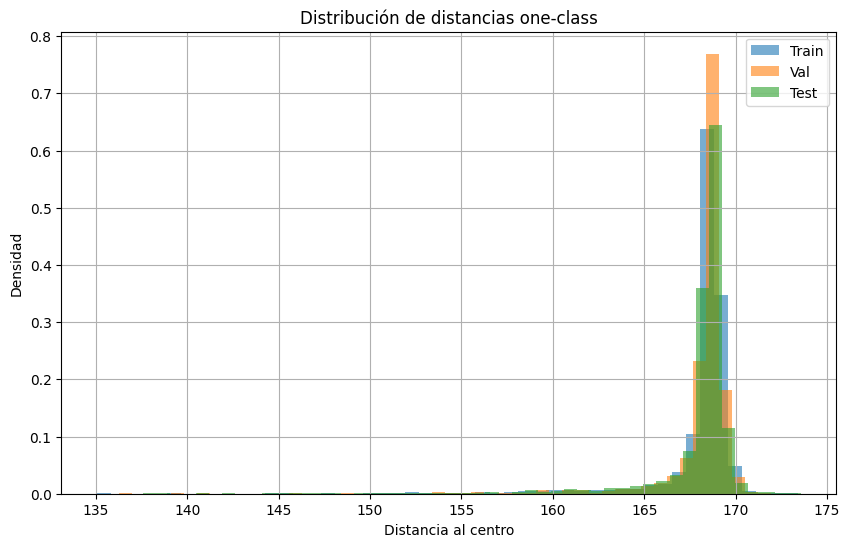

In [133]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(train_dist, bins=50, alpha=0.6, label="Train", density=True)
plt.hist(val_dist, bins=50, alpha=0.6, label="Val", density=True)
plt.hist(test_dist, bins=50, alpha=0.6, label="Test", density=True)

plt.xlabel("Distancia al centro")
plt.ylabel("Densidad")
plt.title("Distribución de distancias one-class")
plt.legend()
plt.grid(True)
plt.show()


# Curvas de entrenamiento (loss)

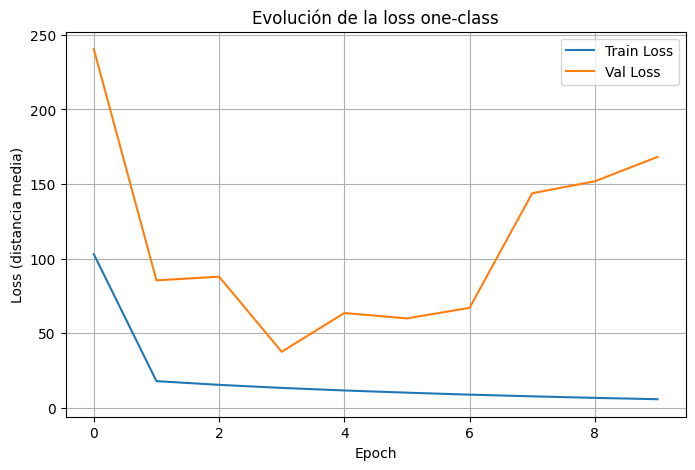

In [134]:
plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (distancia media)")
plt.title("Evolución de la loss one-class")
plt.legend()
plt.grid(True)
plt.show()


# Estadísticas resumidas

In [135]:
def summarize(name, data):
    print(
        f"{name}: "
        f"mean={data.mean():.4f}, "
        f"std={data.std():.4f}, "
        f"min={data.min():.4f}, "
        f"max={data.max():.4f}"
    )

print("\n=== RESUMEN DE DISTANCIAS ===")
summarize("Train", train_dist)
summarize("Val  ", val_dist)
summarize("Test ", test_dist)


=== RESUMEN DE DISTANCIAS ===
Train: mean=167.9439, std=2.8290, min=135.0316, max=173.4287
Val  : mean=168.1491, std=2.3870, min=136.2647, max=171.9375
Test : mean=167.8527, std=3.2267, min=137.5974, max=173.5774


# Umbral por percentil

In [136]:
import numpy as np

# elige tu tolerancia: 95, 97.5, 99
PERCENTILE = 97.5

threshold = np.percentile(val_dist, PERCENTILE)
print("Umbral =", threshold)


Umbral = 169.76677


# Evaluación con genuinos

In [137]:
def reject_rate(dist, thr):
    return float((dist > thr).mean())

print("Rechazo genuinos (Train):", reject_rate(train_dist, threshold))
print("Rechazo genuinos (Val)  :", reject_rate(val_dist, threshold))
print("Rechazo genuinos (Test) :", reject_rate(test_dist, threshold))


Rechazo genuinos (Train): 0.025782937365010798
Rechazo genuinos (Val)  : 0.025030525030525032
Rechazo genuinos (Test) : 0.032237266279819474


# Guardar el umbral

In [179]:
import json

THR_PATH = "/content/oneclass_threshold.json"
with open(THR_PATH, "w") as f:
    json.dump(
        {"percentile": PERCENTILE, "threshold": float(threshold)},
        f,
        indent=2
    )

print("Umbral guardado en", THR_PATH)


Umbral guardado en /content/oneclass_threshold.json


# Reconstruir arquitectura

In [172]:
import torch
import torch.nn as nn
from torchvision import models


# CONFIGURACIÓN

MODEL_PATH = "/content/handbag_oneclass_efficientnet.h5"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DEFINICIÓN DEL MODELO

class EfficientNetEmbedding(nn.Module):
    def __init__(self, embedding_dim=256):
        super().__init__()

        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()

        self.embedding = nn.Sequential(
            nn.Linear(in_features, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )

    def forward(self, x):
        features = self.backbone(x)
        emb = self.embedding(features)
        return emb


# CREAR Y CARGAR PESOS

model = EfficientNetEmbedding(embedding_dim=256).to(device)

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)

model.eval()

print(" Modelo entrenado cargado correctamente")
print("Tipo de model:", type(model))


 Modelo entrenado cargado correctamente
Tipo de model: <class '__main__.EfficientNetEmbedding'>


# Validación Individual de Carteras

In [178]:
import os
import torch
import numpy as np
from PIL import Image


# CONFIGURACIÓN

BAG_DIR = "/content/handbag/112"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".webp")

# thresholds YA calculados previamente
threshold_p95  = 169.608316
threshold_p975 = 169.76677

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()


# CARGAR IMÁGENES

assert os.path.isdir(BAG_DIR), " Carpeta no existe"

imgs = [f for f in os.listdir(BAG_DIR) if f.lower().endswith(IMAGE_EXTS)]
assert len(imgs) > 0, "No hay imágenes válidas"

print(f"📸 Imágenes encontradas: {len(imgs)}")


# CALCULAR DISTANCIAS

distances = []

with torch.no_grad():
    for img_name in imgs:
        img = Image.open(os.path.join(BAG_DIR, img_name)).convert("RGB")
        x = eval_transform(img).unsqueeze(0).to(device)
        emb = model(x)
        dist = torch.sum((emb - center) ** 2, dim=1)
        distances.append(dist.item())


# SCORES POR CARTERA

mean_score = float(np.mean(distances))
p95_score  = float(np.percentile(distances, 95))
max_score  = float(np.max(distances))
std_score  = float(np.std(distances))

print("\n RESULTADOS POR CARTERA")
print(f"Mean : {mean_score:.4f}")
print(f"P95  : {p95_score:.4f}")
print(f"Max  : {max_score:.4f}")
print(f"Std  : {std_score:.4f}")
print(f"N    : {len(distances)}")


# DECISIÓN (ZONA INCONCLUSA)

if max_score <= threshold_p95:
    decision = "AUTÉNTICO"
elif max_score <= threshold_p975:
    decision = "AUTÉNTICO"
else:
    decision = "RECHAZADO"

print("\n🧾 DECISIÓN FINAL")
print("Resultado :", decision)
print("P95 thr   :", threshold_p95)
print("P97.5 thr :", threshold_p975)


# DETALLE POR IMAGEN

print("\n DETALLE POR IMAGEN")
for img, d in zip(imgs, distances):
    print(f"{img:30s} dist={d:.4f}")


📸 Imágenes encontradas: 6

 RESULTADOS POR CARTERA
Mean : 168.7528
P95  : 169.6418
Max  : 169.7078
Std  : 0.7278
N    : 6

🧾 DECISIÓN FINAL
Resultado : AUTÉNTICO
P95 thr   : 169.608316
P97.5 thr : 169.76677

 DETALLE POR IMAGEN
4.webp                         dist=168.1527
6.webp                         dist=168.4277
3.webp                         dist=169.1213
2.webp                         dist=167.6633
5.webp                         dist=169.4437
1.webp                         dist=169.7078


In [92]:
import numpy as np

print("Mean :", np.mean(distances))
print("Max  :", np.max(distances))
print("P90  :", np.percentile(distances, 90))
print("P95  :", np.percentile(distances, 95))
print("Threshold:", threshold)

Mean : 169.08666822645398
Max  : 169.6406707763672
P90  : 169.57596130371093
P95  : 169.60831604003906
Threshold: 169.76677


# Carteras Sintetica

### FAKES: carteras falsas sintéticas creadas con oclusiones, deformaciones y degradaciones fuertes no vistas en entrenamiento para simular réplicas difíciles y evaluar mejor la capacidad de discriminación del modelo.

In [173]:
# ELIMINAR DIRECTORIO FAKE ANTES DE CREAR NUEVOS

import shutil
import os

FAKE_DIR = "/content/data/fake_hard"

if os.path.exists(FAKE_DIR):
    shutil.rmtree(FAKE_DIR)
    print("🗑️ Directorio fake eliminado:", FAKE_DIR)
else:
    print("ℹ Directorio fake no existe, se creará nuevo")


🗑️ Directorio fake eliminado: /content/data/fake_hard


# CREAMOS CARTERAS SINTETICAS

In [174]:
import os
import random
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as F
import torch


# CONFIGURACIÓN

SRC_DIR = "/content/data/split/train"
DST_DIR = "/content/data/fake_hard"
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".webp")

FAKES_PER_BAG = 1
random.seed(42)


# TRANSFORMS

to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

def occlusion_tensor(img):
    _, h, w = img.shape
    occ_w = int(w * random.uniform(0.2, 0.4))
    occ_h = int(h * random.uniform(0.2, 0.4))
    x = random.randint(0, w - occ_w)
    y = random.randint(0, h - occ_h)
    return F.erase(img, y, x, occ_h, occ_w, v=0)

def warp_tensor(img):
    return F.affine(
        img,
        angle=random.uniform(-40, 40),
        translate=(0, 0),
        scale=random.uniform(0.7, 1.1),
        shear=random.uniform(-25, 25)
    )


# GENERAR FAKES HARD

for model_name in os.listdir(SRC_DIR):
    mpath = os.path.join(SRC_DIR, model_name)
    if not os.path.isdir(mpath):
        continue

    for bag in os.listdir(mpath):
        bpath = os.path.join(mpath, bag)
        if not os.path.isdir(bpath):
            continue

        imgs = [f for f in os.listdir(bpath) if f.lower().endswith(IMAGE_EXTS)]
        if not imgs:
            continue

        for k in range(FAKES_PER_BAG):
            fake_bag = f"{bag}_fake_hard{k}"
            dst = os.path.join(DST_DIR, model_name, fake_bag)
            os.makedirs(dst, exist_ok=True)

            for img_name in imgs:
                img = Image.open(os.path.join(bpath, img_name)).convert("RGB")

                x = to_tensor(img)
                x = occlusion_tensor(x)
                x = warp_tensor(x)

                x = transforms.ColorJitter(
                    brightness=0.8,
                    contrast=0.8,
                    saturation=0.8,
                    hue=0.15
                )(x)

                x = transforms.GaussianBlur(kernel_size=9)(x)
                img_fake = to_pil(x)

                img_fake.save(os.path.join(dst, img_name))

print("Carteras fake HARD creadas correctamente")



Carteras fake HARD creadas correctamente


# ROC-AUC

Total carteras: 1048
Genuinas: 184 Fake: 864
ROC-AUC: 0.821057895531401


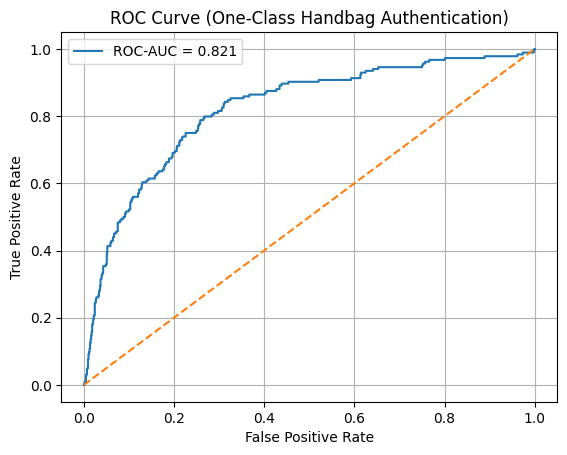

In [176]:
#  ROC-AUC (ONE-CLASS)

import os
import torch
import numpy as np
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


# CONFIGURACIÓN

GENUINE_DIR = "/content/data/split/val"
FAKE_DIR    = "/content/data/fake_hard"
IMAGE_EXTS  = (".jpg", ".jpeg", ".png", ".webp")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()


# FUNCIÓN: SCORE POR CARTERA (MAX)

def score_bags(root_dir, label):
    scores, labels = [], []
    with torch.no_grad():
        for model_name in os.listdir(root_dir):
            mpath = os.path.join(root_dir, model_name)
            if not os.path.isdir(mpath):
                continue
            for bag in os.listdir(mpath):
                bpath = os.path.join(mpath, bag)
                if not os.path.isdir(bpath):
                    continue
                dists = []
                for img_name in os.listdir(bpath):
                    if img_name.lower().endswith(IMAGE_EXTS):
                        img = Image.open(os.path.join(bpath, img_name)).convert("RGB")
                        x = eval_transform(img).unsqueeze(0).to(device)
                        emb = model(x)
                        d = torch.sum((emb - center) ** 2, dim=1).item()
                        dists.append(d)
                if dists:
                    scores.append(max(dists))
                    labels.append(label)
    return scores, labels


# OBTENER SCORES Y LABELS

g_scores, g_labels = score_bags(GENUINE_DIR, 1)   # genuinas
f_scores, f_labels = score_bags(FAKE_DIR, 0)      # fake

scores = np.array(g_scores + f_scores)
y_true = np.array(g_labels + f_labels)

print("Total carteras:", len(scores))
print("Genuinas:", len(g_scores), "Fake:", len(f_scores))


# ROC-AUC

scores_inv = -scores

roc_auc = roc_auc_score(y_true, scores_inv)
print("ROC-AUC:", roc_auc)


# CURVA ROC

fpr, tpr, _ = roc_curve(y_true, scores_inv)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-Class Handbag Authentication)")
plt.legend()
plt.grid(True)
plt.show()
